# Assignment 1: Question 1
**Course:** Machine Learning  
**Student:** Navneet Das  
**Date:** 10 Aug 2026  

---

## Designing and Training Neural Networks — Logic Gates,Backpropagation and Vanishing Gradient

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [24]:
INPUTS=[[0,0],[0,1],[1,0],[1,1]]
AND=[0, 0, 0, 1]
OR=[0, 1, 1 ,1]
XOR = [0, 1, 1, 0]

In [25]:
data = pd.DataFrame({
    "INPUTS_1":[i[0] for i in INPUTS], 
    "INPUTS_2":[i[1] for i in INPUTS], 
    "AND":AND, 
    "OR":OR, 
    "XOR":XOR})
data

,INPUTS_1,INPUTS_2,AND,OR,XOR
0,0,0,0,0,0
1,0,1,0,1,1
2,1,0,0,1,1
3,1,1,1,1,0


In [26]:
X = np.array(INPUTS)

y_and = np.array(AND)
y_or  = np.array(OR)
y_xor = np.array(XOR)

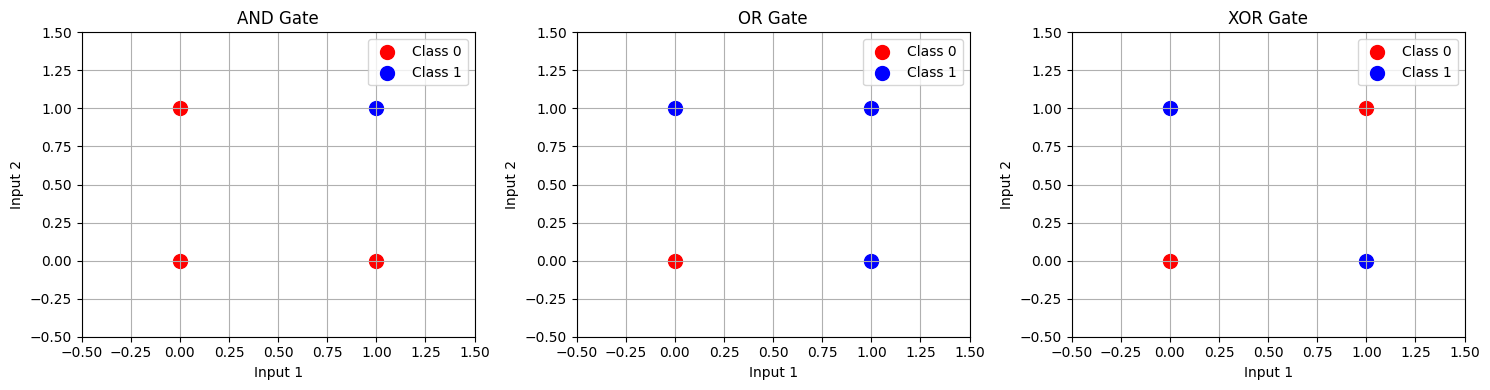

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['AND Gate', 'OR Gate', 'XOR Gate']
datasets = [y_and, y_or, y_xor]

for ax, y_data, title in zip(axes, datasets, titles):
    ax.scatter(X[y_data == 0][:, 0], X[y_data == 0][:, 1], color='red', s=100, label='Class 0')
    ax.scatter(X[y_data == 1][:, 0], X[y_data == 1][:, 1], color='blue', s=100, label='Class 1')
    ax.set_title(title)
    ax.set_xlabel('Input 1')
    ax.set_ylabel('Input 2')
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# Question 2: Forward Propagation

In [28]:
np.random.seed(42)

# Activation functions
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1.0 - a)

# Initialize parameters for 2-2-2-2 network
W1 = np.random.randn(2, 2)
b1 = np.zeros((1, 2))
W2 = np.random.randn(2, 2)
b2 = np.zeros((1, 2))
W3 = np.random.randn(2, 2)
b3 = np.zeros((1, 2))

# Forward propagation function
def forward_pass(X_in, W1, b1, W2, b2, W3, b3):
    Z1 = np.dot(X_in, W1) + b1
    A1 = sigmoid(Z1)
    
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    
    Z3 = np.dot(A2, W3) + b3
    A3 = sigmoid(Z3) # Y_hat
    
    return Z1, A1, Z2, A2, Z3, A3

def compute_mse_loss(Y_true, Y_pred):
    return np.mean(np.square(Y_true - Y_pred))

# One-hot encoded XOR target for 2 output neurons
Y_xor_oh = np.array([[1, 0], [0, 1], [0, 1], [1, 0]])

# Single sample walkthrough
sample_input = X[0:1] # Sample [0, 0]
Z1_s, A1_s, Z2_s, A2_s, Z3_s, A3_s = forward_pass(sample_input, W1, b1, W2, b2, W3, b3)

print("--- Forward Propagation Walkthrough (Single Sample) ---")
print(f"Input: {sample_input}")
print(f"Z1 shape: {Z1_s.shape} | Z1: {Z1_s}")
print(f"A1 shape: {A1_s.shape} | A1: {A1_s}")
print(f"Z2 shape: {Z2_s.shape} | Z2: {Z2_s}")
print(f"A2 shape: {A2_s.shape} | A2: {A2_s}")
print(f"Z3 shape: {Z3_s.shape} | Z3: {Z3_s}")
print(f"Output (A3) shape: {A3_s.shape} | Output: {A3_s}")

# Full dataset initial loss calculation
_, _, _, _, _, Y_hat_init = forward_pass(X, W1, b1, W2, b2, W3, b3)
initial_loss = compute_mse_loss(Y_xor_oh, Y_hat_init)
print(f"\nInitial MSE Loss (Full Dataset): {initial_loss:.6f}")

--- Forward Propagation Walkthrough (Single Sample) ---
Input: [[0 0]]
Z1 shape: (1, 2) | Z1: [[0. 0.]]
A1 shape: (1, 2) | A1: [[0.5 0.5]]
Z2 shape: (1, 2) | Z2: [[0.67252972 0.26664889]]
A2 shape: (1, 2) | A2: [[0.66206937 0.56627003]]
Z3 shape: (1, 2) | Z3: [[-0.57324416  0.09548359]]
Output (A3) shape: (1, 2) | Output: [[0.36048859 0.52385278]]

Initial MSE Loss (Full Dataset): 0.261305


# Question 3: Backpropagation & XOR Training Loop

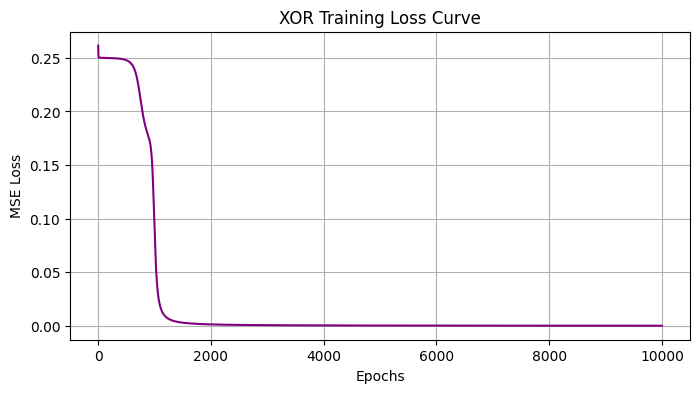


--- Results Table - XOR Predictions ---
Input		Actual XOR	Predicted	Network Output Probability [P(0), P(1)]
[0 0]	0		0		[0.9875 0.0128]
[0 1]	1		1		[0.0108 0.9893]
[1 0]	1		1		[0.0108 0.9893]
[1 1]	0		0		[0.9878 0.0116]


In [29]:
# Re-initialize parameters
np.random.seed(42)
W1 = np.random.randn(2, 2)
b1 = np.zeros((1, 2))
W2 = np.random.randn(2, 2)
b2 = np.zeros((1, 2))
W3 = np.random.randn(2, 2)
b3 = np.zeros((1, 2))

learning_rate = 1.0
epochs = 10000
loss_history = []

# Training loop
for epoch in range(epochs):
    # 1. Forward pass
    Z1, A1, Z2, A2, Z3, A3 = forward_pass(X, W1, b1, W2, b2, W3, b3)
    
    # 2. Loss computation
    loss = compute_mse_loss(Y_xor_oh, A3)
    loss_history.append(loss)
    
    # 3. Backpropagation (Chain Rule)
    N = X.shape[0]
    
    # Output layer gradient
    dLoss_dA3 = (2.0 / N) * (A3 - Y_xor_oh)
    dZ3 = dLoss_dA3 * sigmoid_derivative(A3)
    dW3 = np.dot(A2.T, dZ3)
    db3 = np.sum(dZ3, axis=0, keepdims=True)
    
    # Hidden Layer 2 gradient
    dA2 = np.dot(dZ3, W3.T)
    dZ2 = dA2 * sigmoid_derivative(A2)
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    
    # Hidden Layer 1 gradient
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(A1)
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    
    # 4. Parameter Updates (Gradient Descent)
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

# Plotting Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='purple')
plt.title('XOR Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

# Final Predictions
_, _, _, _, _, final_outputs = forward_pass(X, W1, b1, W2, b2, W3, b3)
predictions = np.argmax(final_outputs, axis=1)

print("\n--- Results Table - XOR Predictions ---")
print("Input\t\tActual XOR\tPredicted\tNetwork Output Probability [P(0), P(1)]")
for idx in range(4):
    inp = X[idx]
    actual = y_xor[idx]
    pred = predictions[idx]
    raw_out = np.round(final_outputs[idx], 4)
    print(f"{inp}\t{actual}\t\t{pred}\t\t{raw_out}")

# Question 4: Small Dataset & Vanishing Gradient Analysis

In [30]:
# Generate synthetic non-linear dataset
X_moons, y_moons = make_moons(n_samples=100, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)

# One-hot encode targets
y_train_oh = np.eye(2)[y_train]

# Re-train 2-2-2-2 network on make_moons dataset
np.random.seed(42)
W1_m = np.random.randn(2, 2)
b1_m = np.zeros((1, 2))
W2_m = np.random.randn(2, 2)
b2_m = np.zeros((1, 2))
W3_m = np.random.randn(2, 2)
b3_m = np.zeros((1, 2))

lr = 0.5
for epoch in range(5000):
    Z1, A1, Z2, A2, Z3, A3 = forward_pass(X_train, W1_m, b1_m, W2_m, b2_m, W3_m, b3_m)
    
    N = X_train.shape[0]
    dZ3 = (2.0 / N) * (A3 - y_train_oh) * sigmoid_derivative(A3)
    dW3 = np.dot(A2.T, dZ3)
    db3 = np.sum(dZ3, axis=0, keepdims=True)
    
    dZ2 = np.dot(dZ3, W3_m.T) * sigmoid_derivative(A2)
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    
    dZ1 = np.dot(dZ2, W2_m.T) * sigmoid_derivative(A1)
    dW1 = np.dot(X_train.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    
    W3_m -= lr * dW3
    b3_m -= lr * db3
    W2_m -= lr * dW2
    b2_m -= lr * db2
    W1_m -= lr * dW1
    b1_m -= lr * db1

# Evaluate test accuracy
_, _, _, _, _, test_outputs = forward_pass(X_test, W1_m, b1_m, W2_m, b2_m, W3_m, b3_m)
test_preds = np.argmax(test_outputs, axis=1)
acc = accuracy_score(y_test, test_preds)
print(f"make_moons Classification Test Accuracy: {acc * 100:.2f}%")

make_moons Classification Test Accuracy: 100.00%


# Part B: 8-Layer Vanishing Gradient Investigation (Sigmoid vs. ReLU)

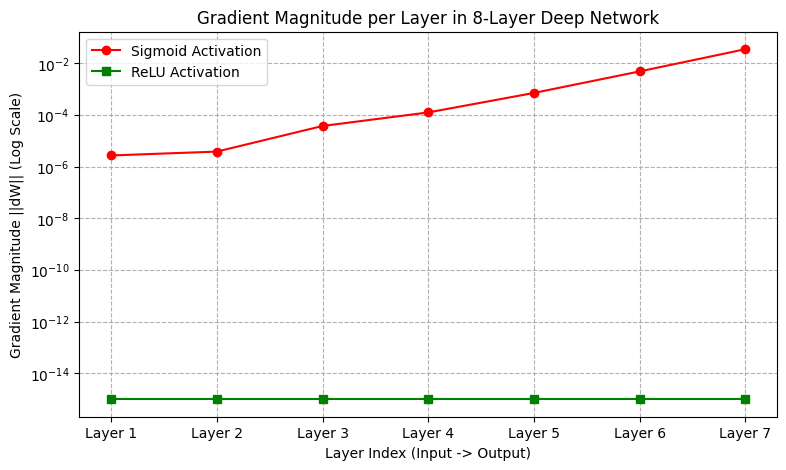

In [32]:
# Activation definitions
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def run_deep_network(activation='sigmoid'):
    np.random.seed(42)
    # 8-layer architecture: Input(2) -> 6 Hidden Layers of 2 neurons -> Output(2)
    layer_dims = [2, 2, 2, 2, 2, 2, 2, 2]
    num_layers = len(layer_dims) - 1
    
    weights = []
    biases = []
    for i in range(num_layers):
        # Use He Initialization for ReLU to prevent neurons from dying, 
        # and standard scaling for Sigmoid
        scale = np.sqrt(2.0 / layer_dims[i]) if activation == 'relu' else 0.5
        weights.append(np.random.randn(layer_dims[i], layer_dims[i+1]) * scale)
        biases.append(np.zeros((1, layer_dims[i+1])))
    
    # Single forward pass
    activations = [X_moons]
    linear_combos = []
    
    curr_A = X_moons
    for i in range(num_layers - 1):
        Z = np.dot(curr_A, weights[i]) + biases[i]
        curr_A = sigmoid(Z) if activation == 'sigmoid' else relu(Z)
        linear_combos.append(Z)
        activations.append(curr_A)
        
    # Output layer (Sigmoid for binary target probability)
    Z_out = np.dot(curr_A, weights[-1]) + biases[-1]
    A_out = sigmoid(Z_out)
    linear_combos.append(Z_out)
    activations.append(A_out)
    
    # Backpropagation to compute gradient norms
    y_moons_oh = np.eye(2)[y_moons]
    N = X_moons.shape[0]
    
    grad_norms = []
    
    # Output layer delta
    dZ = (2.0 / N) * (A_out - y_moons_oh) * sigmoid_derivative(A_out)
    dW = np.dot(activations[-2].T, dZ)
    
    # Add a tiny epsilon (1e-15) so strict 0.0 doesn't crash the log scale plot
    grad_norms.append(np.linalg.norm(dW) + 1e-15)
    
    # Backprop through hidden layers
    for i in range(num_layers - 2, -1, -1):
        dA = np.dot(dZ, weights[i+1].T)
        if activation == 'sigmoid':
            dZ = dA * sigmoid_derivative(activations[i+1])
        else:
            dZ = dA * relu_derivative(linear_combos[i])
            
        dW = np.dot(activations[i].T, dZ)
        grad_norms.append(np.linalg.norm(dW) + 1e-15)
        
    grad_norms.reverse() # Order from Layer 1 to Layer 7
    return grad_norms

# Compare Sigmoid vs ReLU
sigmoid_norms = run_deep_network('sigmoid')
relu_norms = run_deep_network('relu')

# Plotting Gradient Magnitudes
plt.figure(figsize=(9, 5))
layers = [f"Layer {i+1}" for i in range(7)]
plt.plot(layers, sigmoid_norms, marker='o', label='Sigmoid Activation', color='red')
plt.plot(layers, relu_norms, marker='s', label='ReLU Activation', color='green')
plt.yscale('log')
plt.title('Gradient Magnitude per Layer in 8-Layer Deep Network')
plt.xlabel('Layer Index (Input -> Output)')
plt.ylabel('Gradient Magnitude ||dW|| (Log Scale)')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()